In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Directories
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("TF version:", tf.__version__)
print("Setup complete.")

TF version: 2.20.0
Setup complete.


In [2]:
# ============================================================
# CELL 2: LOAD DATA + ASSIGN BATCHES + EXTRACT FAULT ONSETS
# ============================================================
df = pd.read_parquet('100_Batches_IndPenSim_V3.parquet')
print("Raw shape:", df.shape)

# Assign batch numbers when Time resets
df['Batch'] = (df['Time (h)'].diff() < 0).cumsum() + 1
assert df['Batch'].nunique() == 100

FAULT_REF = 'Fault reference(Fault_ref:Fault ref)'

# Per-batch fault onset (first hour where Fault_ref == 1)
fault_onsets = {}
for b in range(91, 101):
    sub = df[(df['Batch'] == b) & (df[FAULT_REF] == 1)]
    if len(sub):
        fault_onsets[b] = float(sub['Time (h)'].iloc[0])

print("\nFault onsets (h):")
for b, t in fault_onsets.items():
    print(f"  Batch {b}: {t:.2f} h")

# Sanity check: no faults in normal batches
assert df[(df['Batch'] <= 90) & (df[FAULT_REF] == 1)].shape[0] == 0
print("\nNo faults in normal batches. OK.")

Raw shape: (113935, 2239)

Fault onsets (h):
  Batch 91: 20.00 h
  Batch 92: 80.00 h
  Batch 93: 70.00 h
  Batch 94: 20.00 h
  Batch 95: 20.00 h
  Batch 96: 70.00 h
  Batch 97: 20.00 h
  Batch 98: 80.00 h
  Batch 99: 20.00 h
  Batch 100: 20.00 h

No faults in normal batches. OK.


In [3]:
# ============================================================
# CELL 3: FEATURE SELECTION
# ============================================================
SELECTED_FEATURES = [
    'Aeration rate(Fg:L/h)',
    'Agitator RPM(RPM:RPM)',
    'Sugar feed rate(Fs:L/h)',
    'Acid flow rate(Fa:L/h)',
    'Base flow rate(Fb:L/h)',
    'Heating/cooling water flow rate(Fc:L/h)',
    'Heating water flow rate(Fh:L/h)',
    'Water for injection/dilution(Fw:L/h)',
    'Air head pressure(pressure:bar)',
    'Substrate concentration(S:g/L)',
    'Dissolved oxygen concentration(DO2:mg/L)',
    'Penicillin concentration(P:g/L)',
    'pH(pH:pH)',
    'Temperature(T:K)',
]
# Verify all present
missing = [c for c in SELECTED_FEATURES if c not in df.columns]
assert not missing, f"Missing: {missing}"

N_FEATURES = len(SELECTED_FEATURES)
print(f"Using {N_FEATURES} features (Time is excluded).")

Using 14 features (Time is excluded).


In [4]:
# ============================================================
# CELL 4: BATCH-LEVEL SPLIT (NO LEAKAGE)
# ============================================================
# Normal batches 1-90. Split by batch, not by window.
all_normal = list(range(1, 91))

rng = np.random.RandomState(SEED)
rng.shuffle(all_normal)

train_batches = sorted(all_normal[:60])   # 60 normal batches: train
val_batches   = sorted(all_normal[60:75]) # 15 normal batches: validation
test_batches  = sorted(all_normal[75:90]) # 15 normal batches: threshold & FAR
faulty_batches = list(range(91, 101))

print(f"Train normal batches: {len(train_batches)}")
print(f"Val   normal batches: {len(val_batches)}")
print(f"Test  normal batches: {len(test_batches)}")
print(f"Faulty batches:       {len(faulty_batches)}")

# Strict assertion: no overlap
assert not (set(train_batches) & set(val_batches))
assert not (set(train_batches) & set(test_batches))
assert not (set(val_batches)   & set(test_batches))
print("Split verified: no batch overlap.")

Train normal batches: 60
Val   normal batches: 15
Test  normal batches: 15
Faulty batches:       10
Split verified: no batch overlap.


In [5]:
# ============================================================
# CELL 5: PER-BATCH SEQUENCES (NO CROSS-BATCH WINDOWS)
# ============================================================
SEQ_LENGTH = 10   # 10 samples × 0.2 h = 2 h

def make_sequences_per_batch(df_in, batches, features, seq_length):
    """
    Generate sliding windows WITHIN each batch.
    Windows never span batch boundaries.
    Returns:
        seqs: (N, seq_length, F)
        meta: DataFrame with Batch and end-time for each window
    """
    seqs = []
    meta_rows = []
    for b in batches:
        sub = df_in[df_in['Batch'] == b].sort_values('Time (h)')
        X = sub[features].values.astype(np.float32)
        times = sub['Time (h)'].values
        for i in range(len(X) - seq_length + 1):
            seqs.append(X[i:i+seq_length])
            meta_rows.append({'Batch': b, 'end_time': times[i+seq_length-1]})
    return np.array(seqs), pd.DataFrame(meta_rows)


# Gather raw (unscaled) sequences per group
X_train_raw, meta_train = make_sequences_per_batch(df, train_batches, SELECTED_FEATURES, SEQ_LENGTH)
X_val_raw,   meta_val   = make_sequences_per_batch(df, val_batches,   SELECTED_FEATURES, SEQ_LENGTH)
X_test_raw,  meta_test  = make_sequences_per_batch(df, test_batches,  SELECTED_FEATURES, SEQ_LENGTH)
X_faulty_raw, meta_faulty = make_sequences_per_batch(df, faulty_batches, SELECTED_FEATURES, SEQ_LENGTH)

print(f"Train  sequences: {X_train_raw.shape}  (from {len(train_batches)} batches)")
print(f"Val    sequences: {X_val_raw.shape}")
print(f"Test   sequences: {X_test_raw.shape}")
print(f"Faulty sequences: {X_faulty_raw.shape}")

# ---- Fit scaler ONLY on training sequences ----
scaler = StandardScaler()
# Reshape to (N*T, F) for fitting
scaler.fit(X_train_raw.reshape(-1, N_FEATURES))

def scale(X):
    s = X.shape
    return scaler.transform(X.reshape(-1, s[-1])).reshape(s).astype(np.float32)

X_train  = scale(X_train_raw)
X_val    = scale(X_val_raw)
X_test   = scale(X_test_raw)
X_faulty = scale(X_faulty_raw)

print("\nScaling done. Train mean≈0, std≈1:")
print(f"  mean={X_train.mean():.4f}, std={X_train.std():.4f}")

Train  sequences: (67595, 10, 14)  (from 60 batches)
Val    sequences: (17170, 10, 14)
Test   sequences: (16835, 10, 14)
Faulty sequences: (11435, 10, 14)

Scaling done. Train mean≈0, std≈1:
  mean=-0.0000, std=0.9636


In [6]:
# ============================================================
# CELL 6: BUILD LSTM-AE
# ============================================================
LATENT_DIM = 8

def build_lstm_ae(seq_len, n_feat, latent_dim):
    inp = keras.Input(shape=(seq_len, n_feat))
    # Encoder
    x = layers.LSTM(32, activation='relu', return_sequences=True)(inp)
    x = layers.LSTM(16, activation='relu', return_sequences=False)(x)
    latent = layers.Dense(latent_dim, activation='relu')(x)
    # Decoder
    x = layers.RepeatVector(seq_len)(latent)
    x = layers.LSTM(16, activation='relu', return_sequences=True)(x)
    x = layers.LSTM(32, activation='relu', return_sequences=True)(x)
    out = layers.TimeDistributed(layers.Dense(n_feat))(x)
    return keras.Model(inp, out)

ae = build_lstm_ae(SEQ_LENGTH, N_FEATURES, LATENT_DIM)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 10, 14)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 10, 32)              │           6,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 10, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 10, 16)              │           1,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 10, 32)              │           6,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 10, 14)              │             462 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,622 (68.84 KB)

 Trainable params: 17,622 (68.84 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ============================================================
# CELL 7: TRAIN
# ============================================================
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ae.fit(
    X_train, X_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, X_val),
    callbacks=[es],
    verbose=1,
)

# ---- Report the BEST epoch, not the last one ----
best_epoch = int(np.argmin(history.history['val_loss']))
print(f"\nStopped at epoch {len(history.history['loss'])}")
print(f"Best epoch:        {best_epoch + 1}")
print(f"Best train loss:   {history.history['loss'][best_epoch]:.6f}")
print(f"Best val   loss:   {history.history['val_loss'][best_epoch]:.6f}")

Epoch 1/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 61s 24ms/step - loss: 0.2703 - val_loss: 0.2066
Epoch 2/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - loss: 0.1661 - val_loss: 0.1808
Epoch 3/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - loss: 0.1499 - val_loss: 0.1735
Epoch 4/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - loss: 0.1422 - val_loss: 0.1621
Epoch 5/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 55s 26ms/step - loss: 0.1355 - val_loss: 0.1625
Epoch 6/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - loss: 0.1260 - val_loss: 0.1703
Epoch 7/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - loss: 0.1199 - val_loss: 0.1337
Epoch 8/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - loss: 0.1127 - val_loss: 0.1374
Epoch 9/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 75s 24ms/step - loss: 0.1074 - val_loss: 0.1313
Epoch 10/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.1045 - val_loss: 0.1386
Epoch 11/100
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 81s 23ms/step - loss: 0.1020 - val_loss: 0.13

In [8]:
# ============================================================
# CELL 7b: SAVE TRAINED MODEL + HISTORY
# ============================================================
import pickle

ae.save('results/lstm_ae.keras')

with open('results/history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("Saved: results/lstm_ae.keras")
print("Saved: results/history.pkl")

Saved: results/lstm_ae.keras
Saved: results/history.pkl


In [9]:
# ============================================================
# CELL 8: RECONSTRUCTION ERRORS
# ============================================================
def recon_error(model, X):
    Xhat = model.predict(X, verbose=0)
    return np.mean(np.square(X - Xhat), axis=(1, 2))

err_train  = recon_error(ae, X_train)
err_val    = recon_error(ae, X_val)
err_test   = recon_error(ae, X_test)     # held-out normal — used for threshold & FAR
err_faulty = recon_error(ae, X_faulty)

print("Train  err: median={:.4f}, IQR=[{:.4f}, {:.4f}]".format(
    np.median(err_train), np.percentile(err_train, 25), np.percentile(err_train, 75)))
print("Val    err: median={:.4f}, IQR=[{:.4f}, {:.4f}]".format(
    np.median(err_val), np.percentile(err_val, 25), np.percentile(err_val, 75)))
print("Test   err: median={:.4f}, IQR=[{:.4f}, {:.4f}]".format(
    np.median(err_test), np.percentile(err_test, 25), np.percentile(err_test, 75)))
print("Faulty err: median={:.4f}, IQR=[{:.4f}, {:.4f}]".format(
    np.median(err_faulty), np.percentile(err_faulty, 25), np.percentile(err_faulty, 75)))

Train  err: median=0.0140, IQR=[0.0066, 0.0296]
Val    err: median=0.0165, IQR=[0.0076, 0.0354]
Test   err: median=0.0137, IQR=[0.0066, 0.0297]
Faulty err: median=0.0385, IQR=[0.0125, 0.1267]


In [10]:
# ============================================================
# CELL 9 : THRESHOLD COMPARISON + P99 SELECTION + FAR
# ============================================================
# We compare four threshold strategies on the HELD-OUT TEST SET,
# then choose P99 to guarantee a ~1% false-alarm budget.
#
# Rationale for P99 over median+3*MAD:
#   - The reconstruction-error distribution is highly right-skewed.
#   - MAD and sigma are both inflated by the tail.
#   - P99 gives a direct, interpretable false-alarm budget.

def mad(x):
    return np.median(np.abs(x - np.median(x)))

thresholds = {
    'mu + 3*sigma':    err_test.mean() + 3 * err_test.std(),
    'median + 3*MAD':  np.median(err_test) + 3 * 1.4826 * mad(err_test),
    'P95':             np.percentile(err_test, 95),
    'P99':             np.percentile(err_test, 99),
}

print("Threshold comparison on held-out normal test set:")
print(f"{'Method':<20}{'Value':>10}{'FAR':>10}{'Flagged normal':>18}")
for name, thr in thresholds.items():
    far = (err_test > thr).mean()
    n_flag = (err_test > thr).sum()
    print(f"{name:<20}{thr:>10.4f}{far*100:>9.2f}%{n_flag:>15d}/{len(err_test)}")

# --- Chosen threshold ---
THRESHOLD = thresholds['P99']
FAR = (err_test > THRESHOLD).mean()

print()
print(f"CHOSEN THRESHOLD: P99 = {THRESHOLD:.4f}")
print(f"FAR (held-out normal, {len(err_test)} windows): {FAR*100:.2f}%")
print(f"Number of false alarms on normal test: {(err_test > THRESHOLD).sum()}")

Threshold comparison on held-out normal test set:
Method                   Value       FAR    Flagged normal
mu + 3*sigma            0.2503     1.14%            192/16835
median + 3*MAD          0.0529    14.40%           2424/16835
P95                     0.1238     5.00%            842/16835
P99                     0.2705     1.00%            169/16835

CHOSEN THRESHOLD: P99 = 0.2705
FAR (held-out normal, 16835 windows): 1.00%
Number of false alarms on normal test: 169


In [11]:
# ============================================================
# CELL 10 (v2): DETECTION METRICS AT P99 THRESHOLD
# ============================================================
flagged_faulty = err_faulty > THRESHOLD
flagged_ratio = flagged_faulty.mean()

meta_faulty = meta_faulty.copy()
meta_faulty['flagged'] = flagged_faulty

batch_detected = meta_faulty.groupby('Batch')['flagged'].any()
FDR_batch = batch_detected.mean()

print(f"Window-level flagged ratio: {flagged_ratio*100:.2f}%  "
      f"({flagged_faulty.sum()} / {len(err_faulty)})")
print(f"Batch-level detection rate: {FDR_batch*100:.1f}%  "
      f"({batch_detected.sum()} / {len(batch_detected)})")
print(f"\nPer-batch detection:")
for b, d in batch_detected.items():
    n_flagged = meta_faulty[(meta_faulty['Batch'] == b) & meta_faulty['flagged']].shape[0]
    n_total   = meta_faulty[meta_faulty['Batch'] == b].shape[0]
    print(f"  Batch {b}: {'DETECTED' if d else 'MISSED'} "
          f"({n_flagged}/{n_total} windows flagged)")

Window-level flagged ratio: 14.64%  (1674 / 11435)
Batch-level detection rate: 100.0%  (10 / 10)

Per-batch detection:
  Batch 91: DETECTED (213/1281 windows flagged)
  Batch 92: DETECTED (210/1141 windows flagged)
  Batch 93: DETECTED (114/1041 windows flagged)
  Batch 94: DETECTED (254/1141 windows flagged)
  Batch 95: DETECTED (139/1046 windows flagged)
  Batch 96: DETECTED (99/1141 windows flagged)
  Batch 97: DETECTED (76/1116 windows flagged)
  Batch 98: DETECTED (155/1141 windows flagged)
  Batch 99: DETECTED (288/1246 windows flagged)
  Batch 100: DETECTED (126/1141 windows flagged)


In [19]:
# ============================================================
# CELL 11: EARLY WARNING TABLE
# ============================================================
# Definition of "detection delay":
#   first flagged window whose end_time >= fault onset, minus fault onset.
# Pre-onset flagged windows are counted separately (they are false alarms
# inside a faulty batch, not detections).

rows = []
for b in faulty_batches:
    onset = fault_onsets[b]

    # Detections = flagged windows at or after fault onset
    sub = meta_faulty[
        (meta_faulty['Batch'] == b) &
        (meta_faulty['flagged']) &
        (meta_faulty['end_time'] >= onset)
    ]
    # Pre-onset false alarms = flagged windows before fault onset
    pre_onset = meta_faulty[
        (meta_faulty['Batch'] == b) &
        (meta_faulty['flagged']) &
        (meta_faulty['end_time'] < onset)
    ]

    if len(sub):
        first_det = float(sub['end_time'].min())
        delay     = first_det - onset
    else:
        first_det = np.nan
        delay     = np.nan

    rows.append({
        'Batch':                          int(b),
        'Fault onset (h)':                round(onset,     2),
        'First detection after onset (h)':round(first_det, 2) if not np.isnan(first_det) else np.nan,
        'Detection delay (h)':            round(delay,     2) if not np.isnan(delay)     else np.nan,
        'Pre-onset false alarms':         int(len(pre_onset)),
    })

early_warn = pd.DataFrame(rows)

# ---- Print cleanly ----
print("=" * 90)
print("EARLY WARNING TABLE")
print("=" * 90)
print(early_warn.to_string(index=False))

# ---- Summary stats ----
valid_delays = early_warn['Detection delay (h)'].dropna()
print()
print(f"Detection delay: min={valid_delays.min():.2f} h | "
      f"median={valid_delays.median():.2f} h | "
      f"max={valid_delays.max():.2f} h")
print(f"Batches detected: {early_warn['Detection delay (h)'].notna().sum()}/"
      f"{len(early_warn)}")
print(f"Total pre-onset false alarms across batches: "
      f"{early_warn['Pre-onset false alarms'].sum()}")

# ---- Save rounded CSV ----
early_warn.to_csv('results/early_warning_table.csv', index=False)
print("\nSaved to results/early_warning_table.csv")

EARLY WARNING TABLE
 Batch  Fault onset (h)  First detection after onset (h)  Detection delay (h)  Pre-onset false alarms
    91             20.0                             21.2                  1.2                       0
    92             80.0                             80.8                  0.8                       8
    93             70.0                             75.6                  5.6                      20
    94             20.0                             20.4                  0.4                       0
    95             20.0                             21.2                  1.2                       0
    96             70.0                             76.8                  6.8                       5
    97             20.0                             21.2                  1.2                       0
    98             80.0                             80.8                  0.8                       0
    99             20.0                             20.2      

In [23]:
# ============================================================
# CELL 12 : DEEPSHAP ON FULL SEQUENCES
# ============================================================
import shap
import time
from tensorflow.keras import layers, Model

# ---- 1. Model with scalar output (reconstruction MSE) ----
inp  = keras.Input(shape=(SEQ_LENGTH, N_FEATURES))
xhat = ae(inp)
err  = layers.Lambda(
    lambda t: tf.reduce_mean(tf.square(t[0] - t[1]), axis=(1, 2))
)([inp, xhat])
err_model = Model(inp, err)

# ---- 2. Background + explained (3D, keep time) ----
rng_shap = np.random.RandomState(SEED)
bg_idx  = rng_shap.choice(len(X_train), 100, replace=False)
background = X_train[bg_idx].astype(np.float32)

exp_idx = rng_shap.choice(len(X_faulty), 200, replace=False)
X_explain_3d = X_faulty[exp_idx].astype(np.float32)

print(f"Background: {background.shape}")
print(f"Explained:  {X_explain_3d.shape}")

# ---- 3. DeepSHAP ----
print("\nRunning DeepSHAP...")
t0 = time.time()
explainer_deep  = shap.GradientExplainer(err_model, background)
shap_values_3d  = explainer_deep.shap_values(X_explain_3d)
if isinstance(shap_values_3d, list):
    shap_values_3d = shap_values_3d[0]
shap_values_3d  = np.array(shap_values_3d)
elapsed = time.time() - t0
print(f"Raw DeepSHAP shape: {shap_values_3d.shape}   ({elapsed/60:.2f} min)")

# ---- 4. FIX: squeeze the trailing output-dim if present ----
if shap_values_3d.ndim == 4 and shap_values_3d.shape[-1] == 1:
    shap_values_3d = shap_values_3d[..., 0]
    print(f"Squeezed to:        {shap_values_3d.shape}")

assert shap_values_3d.ndim == 3, f"Unexpected shape {shap_values_3d.shape}"
assert shap_values_3d.shape[2] == N_FEATURES, "Feature-dim mismatch"

# ---- 5. Aggregate per feature: mean |SHAP| over time and samples ----
mean_abs_deep = np.abs(shap_values_3d).mean(axis=(0, 1))   # (F,)
assert mean_abs_deep.shape == (N_FEATURES,)

feature_importance = pd.DataFrame({
    'Feature':     SELECTED_FEATURES,
    'MeanAbsSHAP': mean_abs_deep,
}).sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)

print("\n=== DeepSHAP feature importance (mean |SHAP| over 10 timesteps × 200 windows) ===")
print(feature_importance.to_string(index=False))

# ---- 6. Save ----
np.save('results/shap_values_deep.npy', shap_values_3d)
np.save('results/X_explain_deep.npy',   X_explain_3d)
np.save('results/bg_idx.npy',           bg_idx)
np.save('results/exp_idx_deep.npy',     exp_idx)
feature_importance.to_csv('results/shap_feature_importance.csv', index=False)

print("\nSaved:")
print("  results/shap_values_deep.npy")
print("  results/X_explain_deep.npy")
print("  results/shap_feature_importance.csv")

Background: (100, 10, 14)
Explained:  (200, 10, 14)

Running DeepSHAP...
Raw DeepSHAP shape: (200, 10, 14, 1)   (0.51 min)
Squeezed to:        (200, 10, 14)

=== DeepSHAP feature importance (mean |SHAP| over 10 timesteps × 200 windows) ===
                                 Feature  MeanAbsSHAP
                        Temperature(T:K)     0.075133
         Heating water flow rate(Fh:L/h)     0.024550
          Substrate concentration(S:g/L)     0.022195
 Heating/cooling water flow rate(Fc:L/h)     0.017326
                               pH(pH:pH)     0.013247
         Air head pressure(pressure:bar)     0.011069
                  Base flow rate(Fb:L/h)     0.007811
    Water for injection/dilution(Fw:L/h)     0.007810
         Penicillin concentration(P:g/L)     0.007764
                   Aeration rate(Fg:L/h)     0.006553
                  Acid flow rate(Fa:L/h)     0.006357
Dissolved oxygen concentration(DO2:mg/L)     0.005952
                 Sugar feed rate(Fs:L/h)     0.005423
    

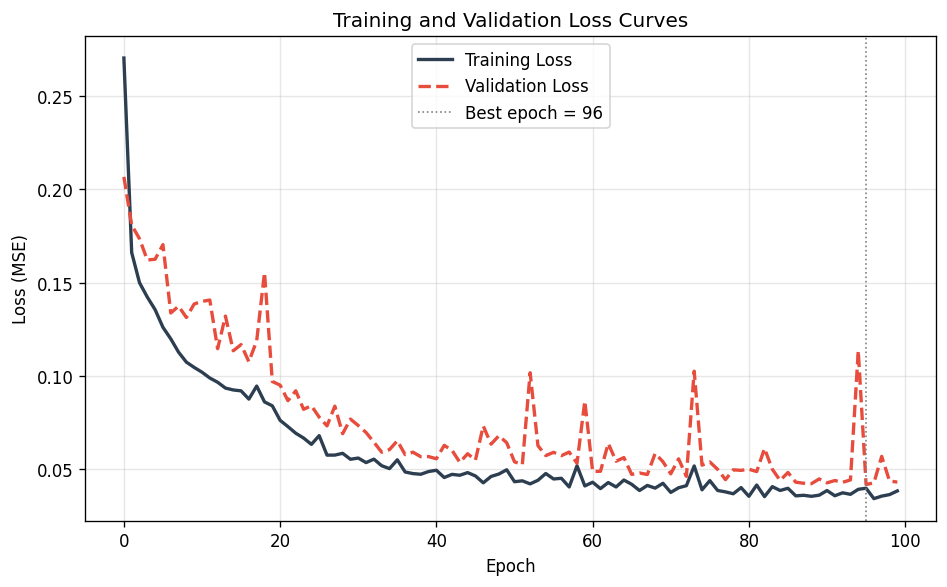

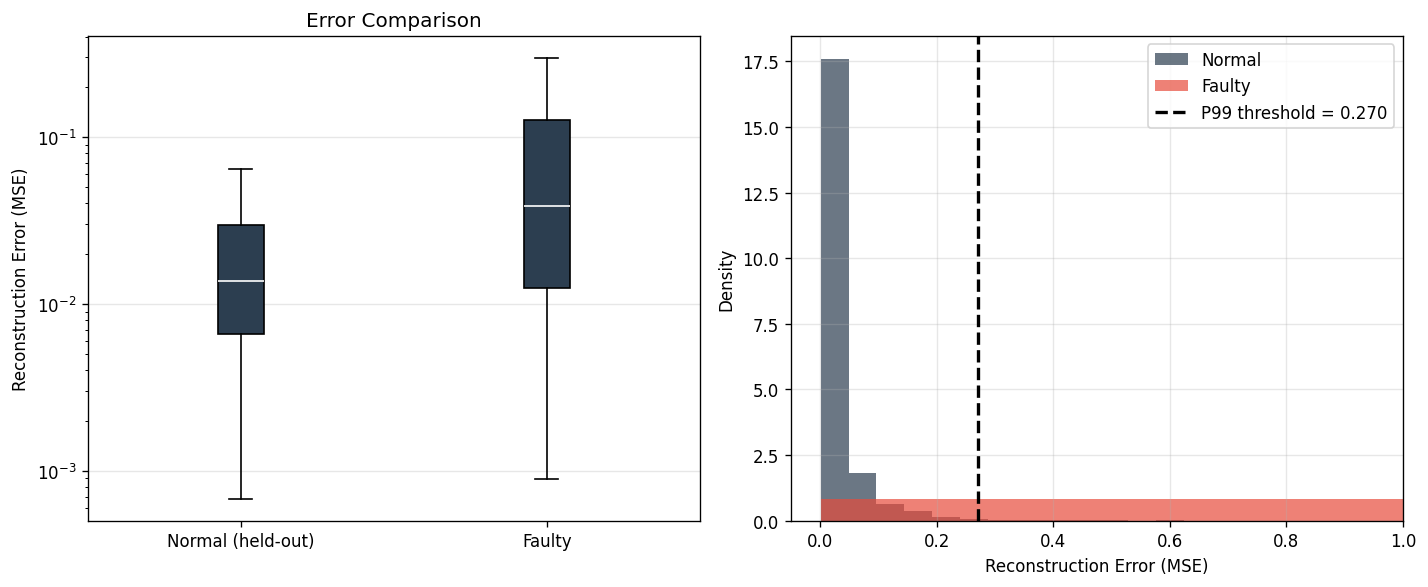

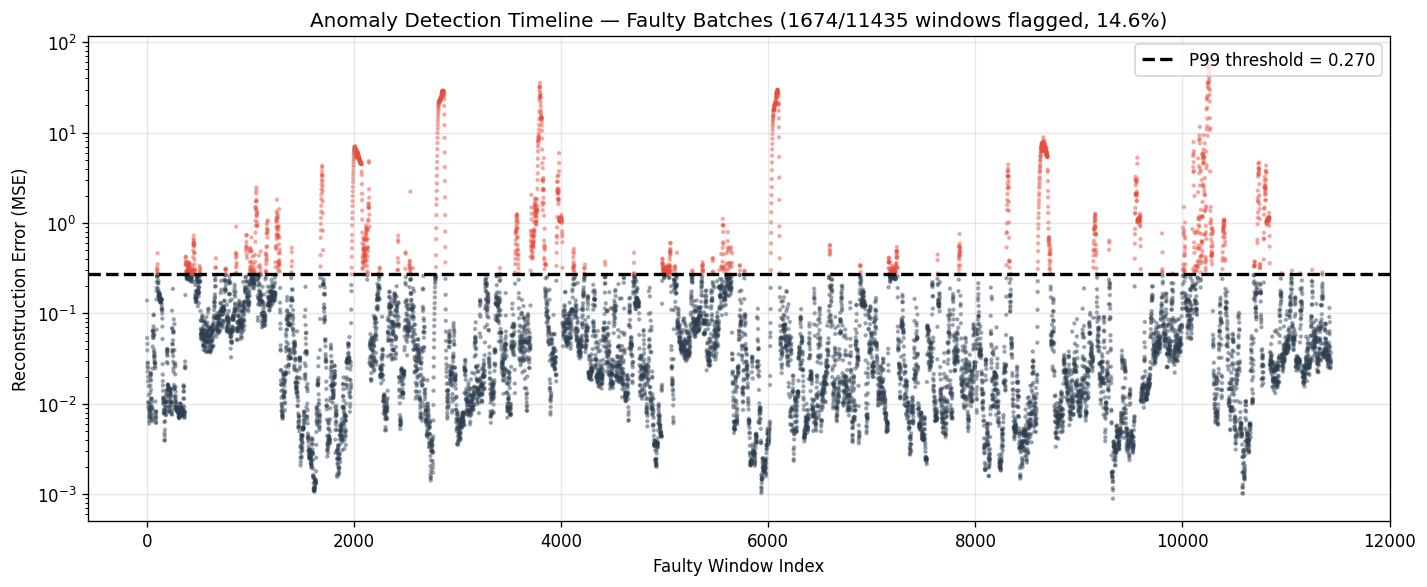

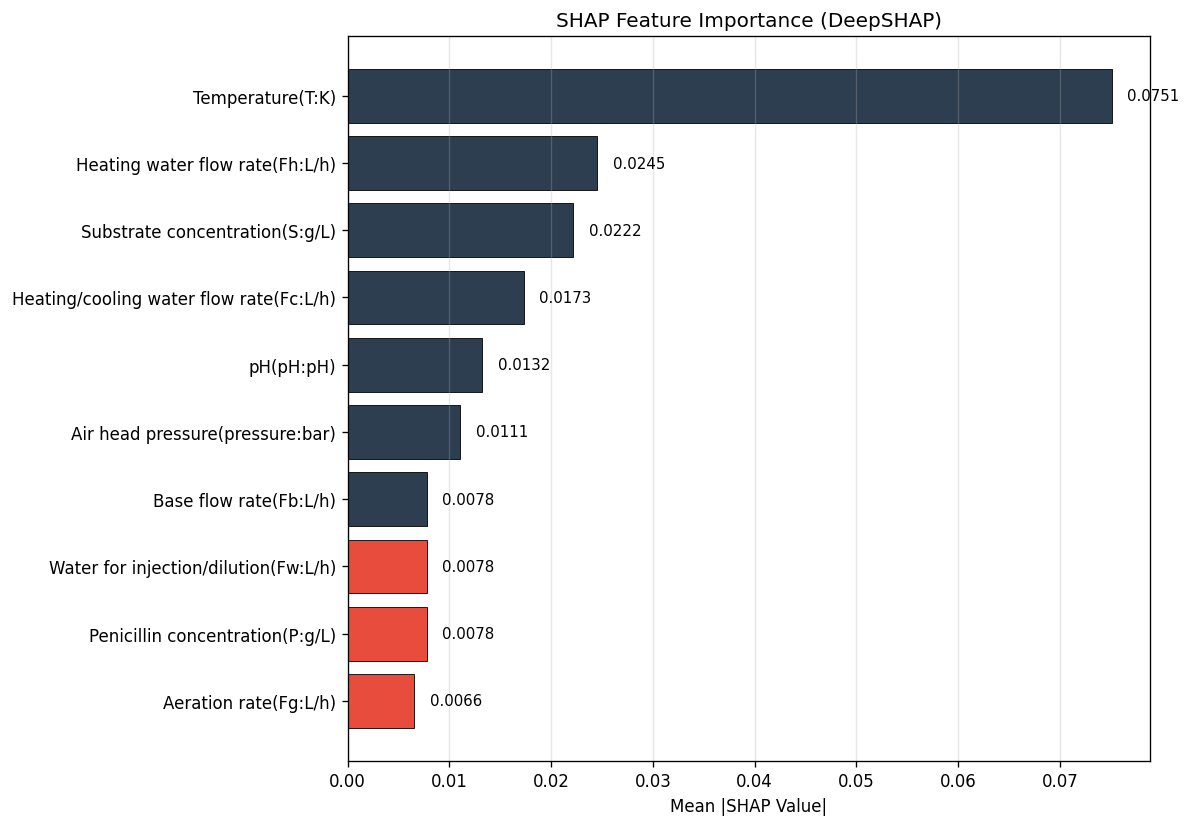

Figures 2-5 saved.


In [27]:
# ============================================================
# CELL 13 : FIGURES 2, 3, 4, 5
# ============================================================
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ---------- Figure 2: training history ----------
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['loss'],     label='Training Loss',   lw=2, color='#2C3E50')
ax.plot(history.history['val_loss'], label='Validation Loss', lw=2, color='#E74C3C', ls='--')
ax.axvline(best_epoch, color='gray', ls=':', lw=1, label=f'Best epoch = {best_epoch+1}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (MSE)')
ax.set_title('Training and Validation Loss Curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/figure2_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------- Figure 3: reconstruction error distributions ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([err_test, err_faulty], labels=['Normal (held-out)', 'Faulty'],
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='#2C3E50', color='black'),
                medianprops=dict(color='white'))
axes[0].set_yscale('log'); axes[0].set_ylabel('Reconstruction Error (MSE)')
axes[0].set_title('Error Comparison'); axes[0].grid(alpha=0.3, axis='y')

axes[1].hist(err_test,   bins=60, alpha=0.7, label='Normal', color='#2C3E50', density=True)
axes[1].hist(err_faulty, bins=60, alpha=0.7, label='Faulty', color='#E74C3C', density=True)
axes[1].axvline(THRESHOLD, color='black', ls='--', lw=2, label=f'P99 threshold = {THRESHOLD:.3f}')
axes[1].set_xlabel('Reconstruction Error (MSE)'); axes[1].set_ylabel('Density')
axes[1].set_xlim(-0.05, 1.0)
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/figure3_reconstruction_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------- Figure 4: anomaly detection timeline ----------
fig, ax = plt.subplots(figsize=(12, 5))
colors = np.where(flagged_faulty, '#E74C3C', '#2C3E50')
ax.scatter(range(len(err_faulty)), err_faulty, c=colors, s=3, alpha=0.35)
ax.axhline(THRESHOLD, color='black', ls='--', lw=2, label=f'P99 threshold = {THRESHOLD:.3f}')
ax.set_yscale('log')
ax.set_xlabel('Faulty Window Index'); ax.set_ylabel('Reconstruction Error (MSE)')
ax.set_title(f'Anomaly Detection Timeline — Faulty Batches '
             f'({flagged_faulty.sum()}/{len(err_faulty)} windows flagged, '
             f'{flagged_ratio*100:.1f}%)')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/figure4_anomaly_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------- Figure 5: SHAP bar plot (DEEPSHAP) ----------
# Load the DeepSHAP feature-importance table we just saved
feature_importance_deep = pd.read_csv('results/shap_feature_importance.csv')

fig, ax = plt.subplots(figsize=(10, 7))
fi_top = feature_importance_deep.head(10).iloc[::-1]
colors = ['#E74C3C' if i < 3 else '#2C3E50' for i in range(len(fi_top))]
ax.barh(fi_top['Feature'], fi_top['MeanAbsSHAP'],
        color=colors, edgecolor='black', linewidth=0.5)
for i, (v, name) in enumerate(zip(fi_top['MeanAbsSHAP'], fi_top['Feature'])):
    ax.text(v + 0.02*fi_top['MeanAbsSHAP'].max(), i, f'{v:.4f}',
            va='center', fontsize=9)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('SHAP Feature Importance (DeepSHAP)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('figures/figure5_shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figures 2-5 saved.")

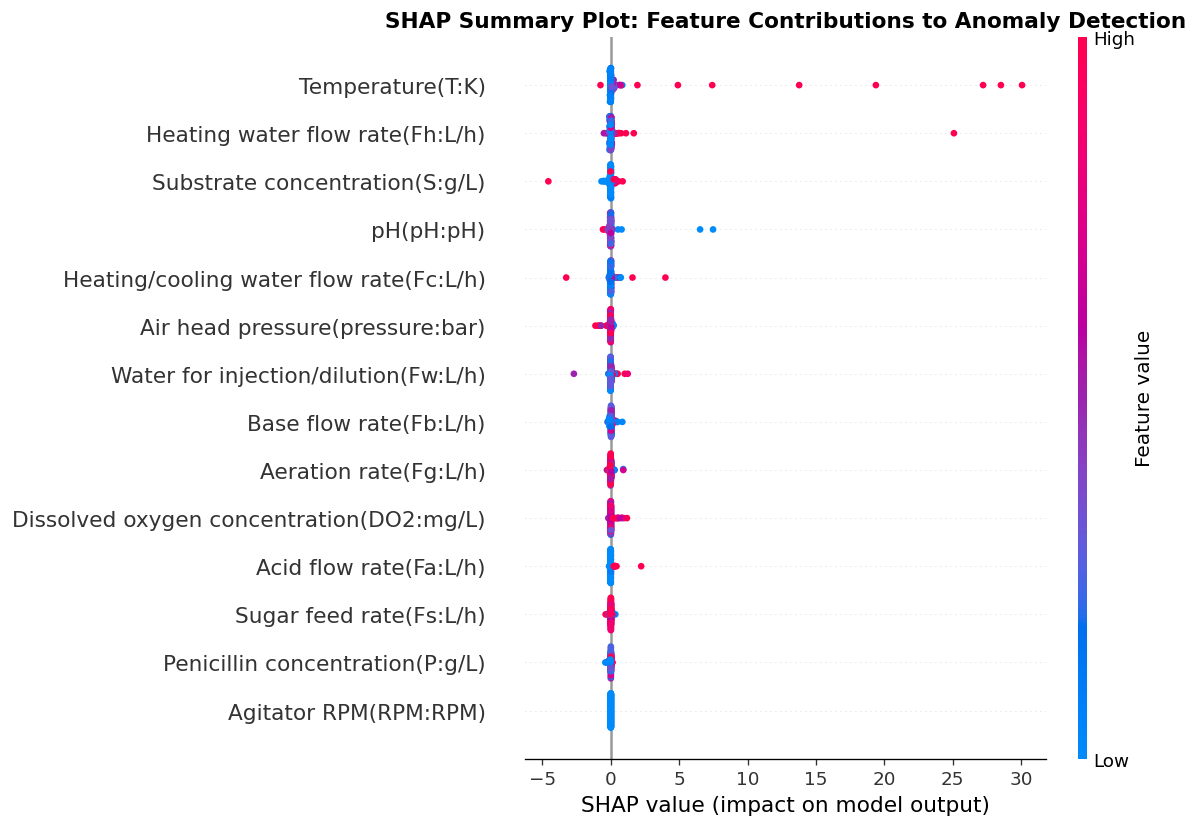

Figure 6 saved.


In [25]:
# ============================================================
# CELL 14 : FIGURE 6 — SHAP SUMMARY (BEESWARM) FROM DEEPSHAP
# ============================================================
# Load saved DeepSHAP arrays
shap_values_3d = np.load('results/shap_values_deep.npy')   # (200, 10, 14)
X_explain_3d   = np.load('results/X_explain_deep.npy')     # (200, 10, 14)

# Aggregate over time: per-feature SHAP contribution per sample = sum over timesteps
shap_per_feat_per_sample = shap_values_3d.sum(axis=1)       # (200, 14)
X_for_color = X_explain_3d.mean(axis=1)                     # (200, 14)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_per_feat_per_sample,
    X_for_color,
    feature_names=SELECTED_FEATURES,
    show=False,
    plot_size=(10, 7),
)
plt.title('SHAP Summary Plot: Feature Contributions to Anomaly Detection',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/figure6_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

Explaining window index 41 (reconstruction MSE = 28.8723)


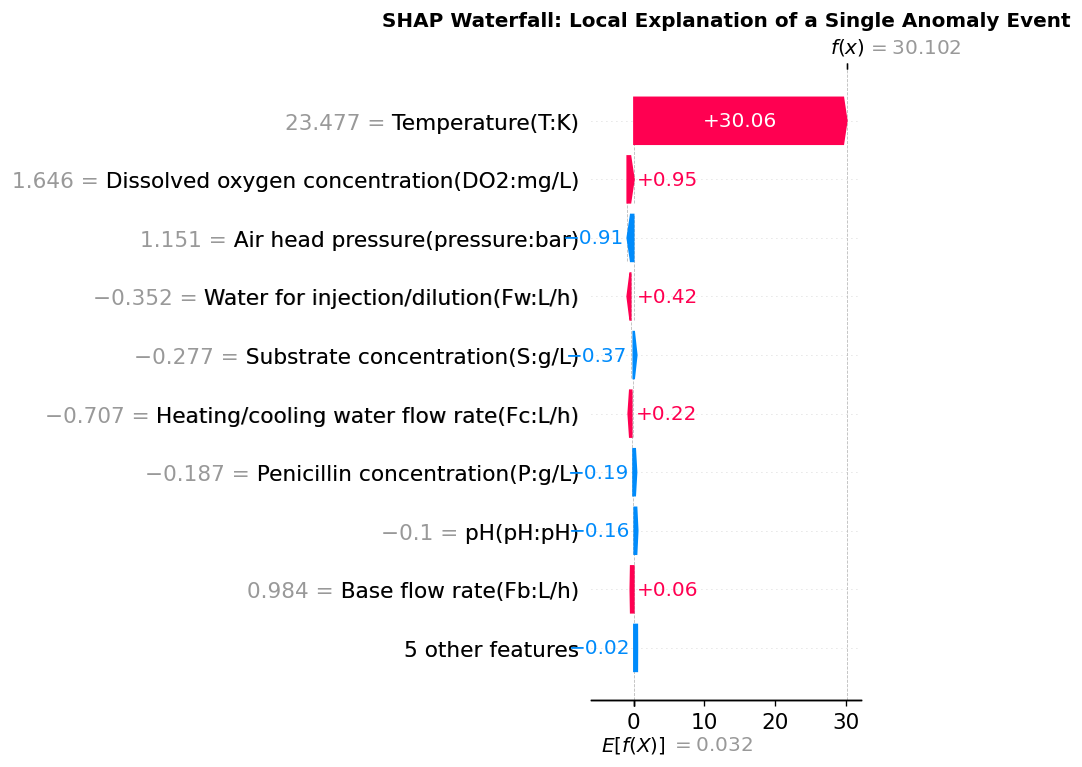

Figure 7 saved.


In [26]:
# ============================================================
# CELL 15 : FIGURE 7 — SHAP WATERFALL FROM DEEPSHAP
# ============================================================
# Pick the most-anomalous explained window
err_of_explained = err_model.predict(X_explain_3d, verbose=0).flatten()
top_local_idx = int(np.argmax(err_of_explained))
print(f"Explaining window index {top_local_idx} "
      f"(reconstruction MSE = {err_of_explained[top_local_idx]:.4f})")

# Correct base value: model output averaged over the SHAP background
base_value = float(np.mean(err_model.predict(background, verbose=0)))

exp = shap.Explanation(
    values        = shap_per_feat_per_sample[top_local_idx],   # (14,)
    base_values   = base_value,
    data          = X_for_color[top_local_idx],                # (14,)
    feature_names = SELECTED_FEATURES,
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(exp, max_display=10, show=False)
plt.title('SHAP Waterfall: Local Explanation of a Single Anomaly Event',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/figure7_shap_waterfall_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

In [28]:
# ============================================================
# CELL 16 (FINAL): FINAL NUMBERS FOR MANUSCRIPT
# ============================================================
print("=" * 65)
print("FINAL MANUSCRIPT NUMBERS")
print("=" * 65)

# --- Explicitly load DeepSHAP feature importance (no ambiguity) ---
feature_importance = pd.read_csv('results/shap_feature_importance.csv')

print("\n--- DATASET ---")
print(f"Total batches:        100")
print(f"Normal batches:        90  (train 60 / val 15 / test 15, by BATCH)")
print(f"Faulty batches:        10  (91-100)")
print(f"Sequence length:      {SEQ_LENGTH}  (= {SEQ_LENGTH*0.2:.1f} h)")
print(f"Features:             {N_FEATURES}")

print("\n--- MODEL ---")
print(f"Best epoch:           {best_epoch + 1}")
print(f"Train loss (best):    {history.history['loss'][best_epoch]:.4f}")
print(f"Val   loss (best):    {history.history['val_loss'][best_epoch]:.4f}")

print("\n--- DETECTION ---")
print(f"Threshold (P99):      {THRESHOLD:.4f}")
print(f"FAR (held-out):       {FAR*100:.2f}%   ({int(FAR*len(err_test))}/{len(err_test)})")
print(f"Window-flagged ratio: {flagged_ratio*100:.2f}%   ({flagged_faulty.sum()}/{len(err_faulty)})")
print(f"Batch-level FDR:      {FDR_batch*100:.1f}%   ({batch_detected.sum()}/{len(batch_detected)})")

print("\n--- EARLY WARNING ---")
vd = early_warn['Detection delay (h)'].dropna()
print(f"Detection delay:      min={vd.min():.2f} h | median={vd.median():.2f} h | max={vd.max():.2f} h")

print("\n--- TOP SHAP FEATURES (DeepSHAP) ---")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:<45}  {row['MeanAbsSHAP']:.4f}")

print("\n--- FILES SAVED ---")
import os
for f in sorted(os.listdir('results')):
    p = os.path.join('results', f)
    if os.path.isfile(p):
        print(f"  results/{f:<35} {os.path.getsize(p)/1024:>10.1f} KB")

FINAL MANUSCRIPT NUMBERS

--- DATASET ---
Total batches:        100
Normal batches:        90  (train 60 / val 15 / test 15, by BATCH)
Faulty batches:        10  (91-100)
Sequence length:      10  (= 2.0 h)
Features:             14

--- MODEL ---
Best epoch:           96
Train loss (best):    0.0398
Val   loss (best):    0.0418

--- DETECTION ---
Threshold (P99):      0.2705
FAR (held-out):       1.00%   (169/16835)
Window-flagged ratio: 14.64%   (1674/11435)
Batch-level FDR:      100.0%   (10/10)

--- EARLY WARNING ---
Detection delay:      min=0.20 h | median=1.00 h | max=6.80 h

--- TOP SHAP FEATURES (DeepSHAP) ---
  1. Temperature(T:K)                               0.0751
  2. Heating water flow rate(Fh:L/h)                0.0245
  3. Substrate concentration(S:g/L)                 0.0222
  4. Heating/cooling water flow rate(Fc:L/h)        0.0173
  5. pH(pH:pH)                                      0.0132

--- FILES SAVED ---
  results/X_explain.npy                             54.8 K

In [20]:
print('meta_faulty' in dir(), 'flagged_faulty' in dir(), 'fault_onsets' in dir())

True True True


In [29]:
import shutil
shutil.make_archive('Pharm_results_backup', 'zip', '.', 'results')
shutil.make_archive('Pharm_figures_backup', 'zip', '.', 'figures')
print("Backups created:")
print("  Pharm_results_backup.zip")
print("  Pharm_figures_backup.zip")

Backups created:
  Pharm_results_backup.zip
  Pharm_figures_backup.zip
